In [3]:
import logging
logging.basicConfig(level=logging.INFO, format='%(name)s - %(levelname)s - %(message)s')
from dotenv import load_dotenv
load_dotenv(dotenv_path=".env")

True

In [14]:
import requests
print(requests.get("https://api.openai.com/v1/models").status_code)

SSLError: HTTPSConnectionPool(host='api.openai.com', port=443): Max retries exceeded with url: /v1/models (Caused by SSLError(SSLCertVerificationError(1, '[SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1016)')))

In [15]:
import requests
response = requests.get("https://api.openai.com/v1/models", verify=False)
print(response.status_code)

403


c:\Users\MAZD6488\AppData\Local\miniconda3\envs\Geo\Lib\site-packages\urllib3\connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'api.openai.com'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


In [6]:
import os
import certifi
os.environ["SSL_CERT_FILE"] = certifi.where()

In [ ]:
# import os
# import certifi

# os.environ.pop("SSL_CERT_FILE", None)
# os.environ.pop("SSL_CERT_DIR", None)
# print(certifi.where())

c:\Users\MAZD6488\AppData\Local\miniconda3\envs\Geo\Lib\site-packages\certifi\cacert.pem


In [7]:
import sys
from pathlib import Path
import os
current_dir = os.getcwd()
project_root = Path(os.path.join(current_dir, "src"))
# project_root = Path(r"C:\my_tools\srh2d-qc-agent\src")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

sys.path


['c:\\my_tools\\srh2d-qc-agent\\src',
 'c:\\Users\\MAZD6488\\AppData\\Local\\miniconda3\\envs\\Geo\\python311.zip',
 'c:\\Users\\MAZD6488\\AppData\\Local\\miniconda3\\envs\\Geo\\DLLs',
 'c:\\Users\\MAZD6488\\AppData\\Local\\miniconda3\\envs\\Geo\\Lib',
 'c:\\Users\\MAZD6488\\AppData\\Local\\miniconda3\\envs\\Geo',
 '',
 'C:\\Users\\MAZD6488\\AppData\\Roaming\\Python\\Python311\\site-packages',
 'C:\\Users\\MAZD6488\\AppData\\Roaming\\Python\\Python311\\site-packages\\win32',
 'C:\\Users\\MAZD6488\\AppData\\Roaming\\Python\\Python311\\site-packages\\win32\\lib',
 'C:\\Users\\MAZD6488\\AppData\\Roaming\\Python\\Python311\\site-packages\\Pythonwin',
 'c:\\Users\\MAZD6488\\AppData\\Local\\miniconda3\\envs\\Geo\\Lib\\site-packages',
 'c:\\Users\\MAZD6488\\AppData\\Local\\miniconda3\\envs\\Geo\\Lib\\site-packages\\win32',
 'c:\\Users\\MAZD6488\\AppData\\Local\\miniconda3\\envs\\Geo\\Lib\\site-packages\\win32\\lib',
 'c:\\Users\\MAZD6488\\AppData\\Local\\miniconda3\\envs\\Geo\\Lib\\site-packa

In [8]:
from srh2d_qc.io.model_loader import load_model
from srh2d_qc.io.parsers.mesh import parse_mesh
from srh2d_qc.io.parsers.materials import parse_materials
from srh2d_qc.io.parsers.run_config import parse_run_config
from srh2d_qc.io.parsers.boundary_conditions.bcs_unified import parse_bcs_from_files

print("Imports OK")


Imports OK


In [9]:
from pathlib import Path
from srh2d_qc.agent.agent_loop import run_agent_once
project_path=Path(current_dir) / "tests" / "model_3"

result = run_agent_once(project_path)


Detected classic SRH-2D .srhgeom format in c:\my_tools\srh2d-qc-agent\tests\model_3\B3216_v4.srhgeom


In [10]:
model=load_model(project_path)
model.materials

Detected classic SRH-2D .srhgeom format in c:\my_tools\srh2d-qc-agent\tests\model_3\B3216_v4.srhgeom


{1: Material(id=1, roughness=0.022, name='Earthen Channel'),
 2: Material(id=2, roughness=0.02, name='Roadway/Parking Lot'),
 3: Material(id=3, roughness=0.025, name='Vegetation - Medium'),
 4: Material(id=4, roughness=0.05, name='Vegetation - Large'),
 5: Material(id=5, roughness=0.025, name='Railroad'),
 6: Material(id=6, roughness=0.025, name='Desert'),
 7: Material(id=7, roughness=0.03, name='Parks/Grass'),
 8: Material(id=8, roughness=0.035, name='Gravel'),
 9: Material(id=9, roughness=0.025, name='Firm Soil'),
 10: Material(id=10, roughness=0.015, name='Concrete'),
 11: Material(id=11, roughness=0.01, name='Vegetation - Small'),
 12: Material(id=12, roughness=0.12, name='Developed Medium Intensity')}

In [11]:
sorted(model.materials.keys())

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

In [12]:
from srh2d_qc.agent.agent_core import SRH2D_QCAgent
from srh2d_qc.agent.chat_agent import SRH2DChatAgent
from srh2d_qc.agent.agent_tools import ModelTools
from srh2d_qc.llm.reasoner import LLMReasoner

agent = SRH2D_QCAgent(project_path, llm_reasoner=LLMReasoner())
agent.load()

# # Create tools instance to check data sizes
# tools = ModelTools(agent.model)

# # Check how much data gets sent
# original_size = len(str(tools.get_all_model_class(
#     include_mesh=True, include_materials=True, include_bcs=True, include_run_config=True
# )))
# optimized_size = len(str(tools.get_all_model_class(
#     include_materials=True, include_bcs=True  # Only what's needed
# )))
# print(f"Full model: {original_size} bytes")
# print(f"Materials+BCs: {optimized_size} bytes")
# print(f"Savings: {100*(original_size-optimized_size)/original_size:.1f}%")

agent.run_qc()

chat = SRH2DChatAgent(agent)
# print(chat.ask("can you list the boundary conditions in the model? and their types? and the nodes they are applied to?"))

Detected classic SRH-2D .srhgeom format in c:\my_tools\srh2d-qc-agent\tests\model_3\B3216_v4.srhgeom


In [13]:
chat.ask("plot the mesh (x vs y)")

openai._base_client - INFO - Retrying request to /chat/completions in 0.398496 seconds
openai._base_client - INFO - Retrying request to /chat/completions in 0.754797 seconds


APIConnectionError: Connection error.

In [9]:
dd=agent.tools.get_mesh_node_coordinates()

In [14]:
chat.ask(f"plot these coordinates {dd} ")  

httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
openai._base_client - INFO - Retrying request to /chat/completions in 0.409802 seconds
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
openai._base_client - INFO - Retrying request to /chat/completions in 0.885275 seconds
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


RateLimitError: Error code: 429 - {'error': {'message': 'Request too large for gpt-4o-mini in organization org-SpQZdmFPYb8mceXVyE9a1Da3 on tokens per min (TPM): Limit 200000, Requested 228926. The input or output tokens must be reduced in order to run successfully. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}

In [12]:
chat = SRH2DChatAgent(agent)  # New conversation, no history
chat.ask("plot the mesh")

httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
srh2d_qc.agent.chat_agent - INFO - Tool call: get_mesh_node_coordinates({})
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
openai._base_client - INFO - Retrying request to /chat/completions in 0.418657 seconds
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 429 Too Many Requests"
openai._base_client - INFO - Retrying request to /chat/completions in 0.898981 seconds
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 429 Too Many Requests"


RateLimitError: Error code: 429 - {'error': {'message': 'Request too large for gpt-4o-mini in organization org-SpQZdmFPYb8mceXVyE9a1Da3 on tokens per min (TPM): Limit 200000, Requested 229111. The input or output tokens must be reduced in order to run successfully. Visit https://platform.openai.com/account/rate-limits to learn more.', 'type': 'tokens', 'param': None, 'code': 'rate_limit_exceeded'}}

In [10]:
import pandas as pd

df = pd.read_csv(r"C:\dev\srh2d-qc-agent\mesh_nodes.csv")
df

,node_id,x,y
0,1,966762.315087,2.729300e+07
1,2,966764.038490,2.729299e+07
2,3,966799.950041,2.729301e+07
3,4,966801.673443,2.729301e+07
4,5,966768.587579,2.729300e+07
...,...,...,...
24657,24658,962758.836197,2.729084e+07
24658,24659,962797.120271,2.729084e+07
24659,24660,963223.490292,2.729079e+07
24660,24661,963223.106656,2.729084e+07


<Axes: xlabel='x', ylabel='y'>

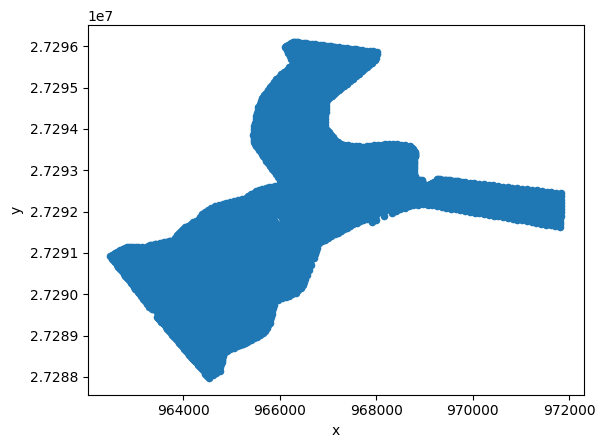

In [11]:
df.plot.scatter(x='x', y='y')

In [8]:
from srh2d_qc.agent.agent_core import SRH2D_QCAgent
from srh2d_qc.agent.chat_agent import SRH2DChatAgent
from srh2d_qc.llm.reasoner import LLMReasoner
agent = SRH2D_QCAgent(project_path, llm_reasoner=LLMReasoner())
agent.load()
agent.run_qc()

chat = SRH2DChatAgent(agent)
# print(chat.ask("create a table of materials in the model with their properties"))
print(chat.ask("can you list the materials in the model and their properties like a table?"))

Detected classic SRH-2D .srhgeom format in c:\dev\srh2d-qc-agent\tests\model_3\B3216_v4.srhgeom


httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
srh2d_qc.agent.chat_agent - INFO - Tool call: get_material_table({})
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


Here is a table of the materials in the model along with their properties:

| Material ID | Name                           | Roughness |
|-------------|--------------------------------|-----------|
| 1           | Earthen Channel                | 0.022     |
| 2           | Roadway/Parking Lot           | 0.020     |
| 3           | Vegetation - Medium            | 0.025     |
| 4           | Vegetation - Large             | 0.050     |
| 5           | Railroad                       | 0.025     |
| 6           | Desert                         | 0.025     |
| 7           | Parks/Grass                    | 0.030     |
| 8           | Gravel                         | 0.035     |
| 9           | Firm Soil                     | 0.025     |
| 10          | Concrete                       | 0.015     |
| 11          | Vegetation - Small             | 0.010     |
| 12          | Developed Medium Intensity     | 0.120     |

If you need more information, feel free to ask!


In [9]:
print(chat.ask("can you create a table of the nodes in the mesh with their coordinates? and make it as a file called test_download_data.csv?"))

httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
srh2d_qc.agent.chat_agent - INFO - Tool call: export_mesh_nodes_csv({"output_dir": "."})
srh2d_qc.agent.agent_tools - INFO - Exported mesh nodes to mesh_nodes.csv
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


The table of nodes in the mesh, along with their coordinates, has been successfully exported to a file named "mesh_nodes.csv". If you need any further assistance or additional exports, feel free to ask!


In [ ]:
print("\n--- Testing plotting tool ---")
print(chat.ask("Plot the mesh nodes (x coordinates vs y coordinates) and save it as a scatter plot."))


--- Testing different queries ---

1. Material query:


httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
srh2d_qc.agent.chat_agent - INFO - Tool call: get_material_table({})
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


The model has one material defined:

- **ID**: 1
- **Name**: default
- **Roughness**: 0.01

2. Mesh query:


httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
srh2d_qc.agent.chat_agent - INFO - Tool call: get_element_count({})
srh2d_qc.agent.chat_agent - INFO - Tool call: get_node_count({})
httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


The mesh contains 6,000 elements and 6,321 nodes.
